In [1]:

import os
from pathlib import Path

# Automatically detect the current folder where the notebook is running
current_dir = Path().resolve()

# Look for diabetic_data.csv in the current folder or subfolders
csv_candidates = list(current_dir.glob("**/diabetic_data.csv"))

if csv_candidates:
    DATA_CSV_PATH = csv_candidates[0]
    print(f"✅ Found dataset: {DATA_CSV_PATH}")
else:
    raise FileNotFoundError("❌ Could not find 'diabetic_data.csv' in this folder.")


✅ Found dataset: C:\Users\User\OneDrive\Desktop\ML-ASSESSMENT\diabetic_data.csv


In [2]:

import pandas as pd

df = pd.read_csv(DATA_CSV_PATH)
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
df.head(3)


✅ Dataset loaded successfully!
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [3]:

import numpy as np

df = df.copy()

# Drop super-sparse columns
for col in ["weight"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Binary target: readmitted within 30 days
df["y"] = (df["readmitted"].astype(str).str.strip() == "<30").astype(int)

# Numeric columns (cast safely)
num_cols = [
    "time_in_hospital","num_lab_procedures","num_procedures","num_medications",
    "number_outpatient","number_emergency","number_inpatient","number_diagnoses"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Categorical columns present in your file
cat_cols = [c for c in [
    "race","gender","age","admission_type_id","discharge_disposition_id","admission_source_id",
    "payer_code","medical_specialty","max_glu_serum","A1Cresult",
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride","acetohexamide",
    "glipizide","glyburide","tolbutamide","pioglitazone","rosiglitazone","acarbose","miglitol",
    "troglitazone","tolazamide","insulin","glyburide-metformin","glipizide-metformin",
    "glimepiride-pioglitazone","metformin-rosiglitazone","metformin-pioglitazone",
    "change","diabetesMed"
] if c in df.columns]

id_cols = [c for c in ["encounter_id","patient_nbr"] if c in df.columns]

print("Num cols:", len(num_cols), "Cat cols:", len(cat_cols))
df[["y"] + num_cols + cat_cols].head(3)


Num cols: 8 Cat cols: 33


,y,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,race,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,0,1,41,0,1,0,0,0,1,Caucasian,...,No,No,No,No,No,No,No,No,No,No
1,0,3,59,0,18,0,0,0,9,Caucasian,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,0,2,11,5,13,2,0,1,6,AfricanAmerican,...,No,No,No,No,No,No,No,No,No,Yes


In [4]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
import pandas as pd

groups = df["patient_nbr"] if "patient_nbr" in df.columns else pd.Series(range(len(df)))
y = df["y"].astype(int).values

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median"))])  # fast
cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    [("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
    remainder="drop",
    verbose_feature_names_out=False
)

# 3-fold grouped CV for speed
gkf = GroupKFold(n_splits=3)

# Fit preprocessor on first training split only (no target leakage)
tr0, va0 = next(gkf.split(df[num_cols + cat_cols], y, groups))
pre.fit(df.loc[tr0, num_cols + cat_cols], y[tr0])

# Transform full dataset to numeric matrix
X_all = pre.transform(df[num_cols + cat_cols])

# Recover feature names after OHE
feature_names = []
for name, trans, cols in pre.transformers_:
    if name == "num":
        feature_names += list(cols)
    elif name == "cat":
        feature_names += list(trans.named_steps["ohe"].get_feature_names_out(cols))

len(feature_names), feature_names[:10]


(238,
 ['time_in_hospital',
  'num_lab_procedures',
  'num_procedures',
  'num_medications',
  'number_outpatient',
  'number_emergency',
  'number_inpatient',
  'number_diagnoses',
  'race_?',
  'race_AfricanAmerican'])

In [5]:

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
import numpy as np

vt = VarianceThreshold(0.0)
X_vt = vt.fit_transform(X_all)
feat_vt = [n for n, keep in zip(feature_names, vt.get_support()) if keep]

# Mutual information (can take a few seconds)
mi = mutual_info_classif(X_vt, y, random_state=42, discrete_features='auto')
order = np.argsort(mi)[::-1]
TOP_K = 50  # smaller = faster; tweak if you want
sel_idx = order[:TOP_K]
X_sel = X_vt[:, sel_idx]
sel_names = [feat_vt[i] for i in sel_idx]

len(sel_names), sel_names[:10]


(50,
 ['chlorpropamide_No',
  'tolbutamide_No',
  'repaglinide_No',
  'rosiglitazone_No',
  'acarbose_No',
  'glimepiride_No',
  'acetohexamide_No',
  'glimepiride-pioglitazone_No',
  'metformin-pioglitazone_No',
  'troglitazone_No'])

In [6]:

from sklearn.ensemble import RandomForestClassifier

models = {
    "rf": RandomForestClassifier(
        n_estimators=150,   # fewer trees = faster
        max_depth=8,       # limit depth = faster
        random_state=42,
        n_jobs=-1
    )
}
list(models.keys())


['rf']

In [7]:

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.base import clone
import numpy as np

def eval_scores(y_true, y_prob):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
    }

cv_results = {}
for name, model in models.items():
    yt_all, yp_all = [], []
    for tr, va in gkf.split(X_sel, y, groups):
        m = clone(model)
        m.fit(X_sel[tr], y[tr])
        yp = m.predict_proba(X_sel[va])[:, 1]
        yt_all.append(y[va]); yp_all.append(yp)
    yt_all = np.concatenate(yt_all); yp_all = np.concatenate(yp_all)
    cv_results[name] = eval_scores(yt_all, yp_all)

cv_results


{'rf': {'roc_auc': 0.6651910319714801,
  'pr_auc': 0.21453206692062138,
  'brier': 0.09548737095546568}}

In [8]:

from sklearn.calibration import CalibratedClassifierCV
import numpy as np
from sklearn.base import clone

calib = {}
for name, model in models.items():
    yt_all, yp_all = [], []
    for tr, va in gkf.split(X_sel, y, groups):
        base = clone(model).fit(X_sel[tr], y[tr])
        # quick 3-fold internal CV for calibration
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_sel[tr], y[tr])
        yp = cal.predict_proba(X_sel[va])[:, 1]
        yt_all.append(y[va]); yp_all.append(yp)
    yt_all = np.concatenate(yt_all); yp_all = np.concatenate(yp_all)
    calib[name] = {"y": yt_all, "p": yp_all, "scores": eval_scores(yt_all, yp_all)}

calib


{'rf': {'y': array([0, 0, 0, ..., 0, 0, 0], shape=(101766,)),
  'p': array([0.07149181, 0.0944584 , 0.07132825, ..., 0.05954281, 0.26417299,
         0.09544806], shape=(101766,)),
  'scores': {'roc_auc': 0.6652457348024693,
   'pr_auc': 0.21502235302088174,
   'brier': 0.09503740073738613}}}

Best by Brier: rf {'roc_auc': 0.6652457348024693, 'pr_auc': 0.21502235302088174, 'brier': 0.09503740073738613}


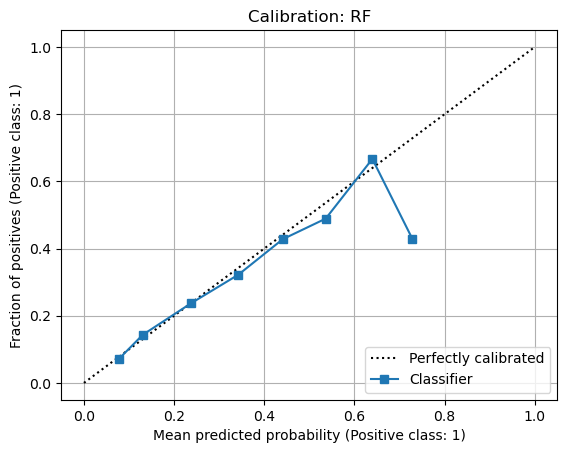

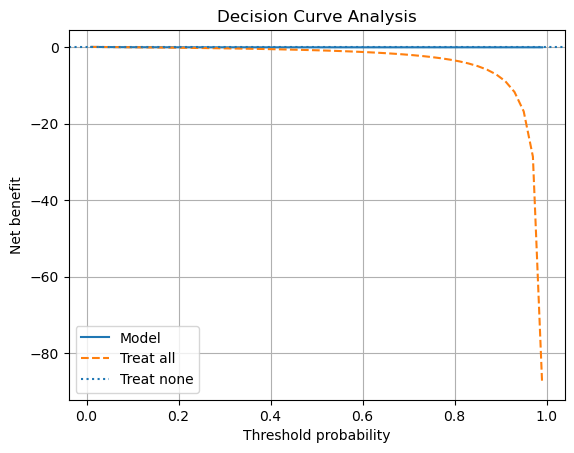

In [9]:

import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay
import numpy as np

best = min(calib.keys(), key=lambda k: calib[k]["scores"]["brier"])
print("Best by Brier:", best, calib[best]["scores"])

# Calibration curve
CalibrationDisplay.from_predictions(calib[best]["y"], calib[best]["p"], n_bins=10)
plt.title(f"Calibration: {best.upper()}"); plt.grid(True); plt.show()

# Simple Decision Curve Analysis
def decision_curve(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 50)
    N = len(y_true)
    nbs = []
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = ((pred==1)&(y_true==1)).sum()
        FP = ((pred==1)&(y_true==0)).sum()
        nb = (TP/N) - (FP/N)*(pt/(1-pt))
        nbs.append(nb)
    return thresholds, np.array(nbs)

ths, nbs = decision_curve(calib[best]["y"], calib[best]["p"])
plt.figure()
plt.plot(ths, nbs, label="Model")
prev = calib[best]["y"].mean()
plt.plot(ths, prev - (1 - prev) * (ths/(1-ths)), linestyle="--", label="Treat all")
plt.axhline(0, linestyle=":", label="Treat none")
plt.xlabel("Threshold probability"); plt.ylabel("Net benefit")
plt.title("Decision Curve Analysis"); plt.legend(); plt.grid(True); plt.show()


In [12]:

# You can skip this cell on first run if you want it even faster.
from sklearn.inspection import permutation_importance
from sklearn.base import clone
import pandas as pd

best_model = clone(models["rf"]).fit(X_sel, y)
r = permutation_importance(best_model, X_sel, y, n_repeats=3, random_state=42, n_jobs=-1)  # n_repeats=3 = faster

imp = pd.DataFrame({
    "feature": sel_names,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

imp.head(20)


,feature,importance_mean,importance_std
0,chlorpropamide_No,0.0,0.0
1,tolbutamide_No,0.0,0.0
2,repaglinide_No,0.0,0.0
3,rosiglitazone_No,0.0,0.0
4,acarbose_No,0.0,0.0
5,glimepiride_No,0.0,0.0
6,acetohexamide_No,0.0,0.0
7,glimepiride-pioglitazone_No,0.0,0.0
8,metformin-pioglitazone_No,0.0,0.0
9,troglitazone_No,0.0,0.0


In [13]:
# === 10. Summary ==
print("Pre-calibration metrics:")
for k, v in cv_results.items():
    print(k.upper(), v)

print("\nPost-calibration metrics:")
for k, v in calib.items():
    print(k.upper(), v["scores"])

print("\nBest model by Brier:", best.upper())


Pre-calibration metrics:
RF {'roc_auc': 0.6651910319714801, 'pr_auc': 0.21453206692062138, 'brier': 0.09548737095546568}

Post-calibration metrics:
RF {'roc_auc': 0.6652457348024693, 'pr_auc': 0.21502235302088174, 'brier': 0.09503740073738613}

Best model by Brier: RF
